## (0) Loading Bibs and Data 

In [27]:
import pandas as pd
import matplotlib.pyplot as plt 
from ydata_profiling import ProfileReport
from collections import Counter
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

%matplotlib inline

In [3]:
df = pd.read_csv('../../data/08_PlayStoreReviews.csv')
df.drop(columns=['reviewId', 'app_name'], inplace=True)
print(df.shape)
df.head(3)

(3011, 3)


,content,sentiment_polarity,sentiment
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness
2,app bom prát fácil entend porém algum vend man...,positive,sadness


## (1) Data Overview an Descriptive Statistics

In [4]:
df.dtypes # data types

content               object
sentiment_polarity    object
sentiment             object
dtype: object

In [5]:
df[df.duplicated()] # check duplicated rows

,content,sentiment_polarity,sentiment


In [6]:
df.isna().sum() # missing values per feature

content               1
sentiment_polarity    0
sentiment             0
dtype: int64

In [7]:
df.describe()

,content,sentiment_polarity,sentiment
count,3010,3011,3011
unique,3010,3,7
top,app shope razoá apes fácil utiliz apresent alg...,negative,disgust
freq,1,1742,952


In [9]:
df.sentiment.value_counts() # check the emotions balance

sentiment
disgust      952
sadness      864
anger        743
happiness    319
neutral       82
fear          47
surprise       4
Name: count, dtype: int64

In [10]:
# Generate the report
profile = ProfileReport(df,title="PlayStoreReviews Profile")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00,  6.34it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## (2) Statistical and structural analyses of the text

In [12]:
# Distribuição do tamanho dos textos
df['n_chars'] = df['content'].str.len()
df['n_words'] = df['content'].str.split().str.len()

print(df['n_chars'].describe())
print(80*"-")
print(df['n_words'].describe())

count    3010.000000
mean      159.344186
std        66.982092
min         4.000000
25%       111.000000
50%       158.000000
75%       211.000000
max       339.000000
Name: n_chars, dtype: float64
--------------------------------------------------------------------------------
count    3010.000000
mean       29.534219
std        12.308608
min         1.000000
25%        21.000000
50%        29.000000
75%        39.000000
max        68.000000
Name: n_words, dtype: float64


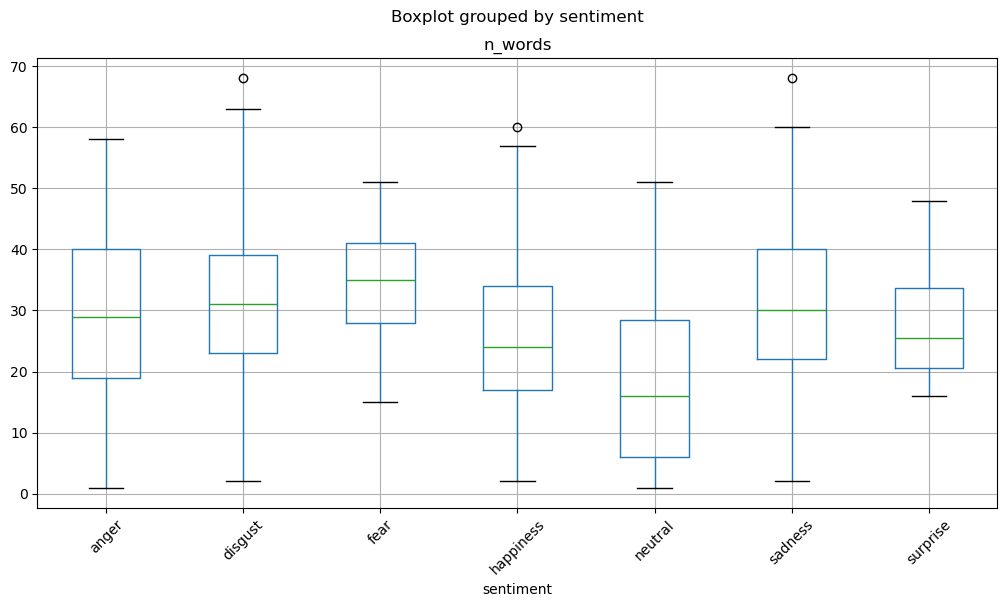

In [13]:
# Histogramas por sentimento
df.boxplot(column='n_words', by='sentiment', figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [17]:
# Número de textos vazios ou quase vazios
print((df['content'].str.strip().str.len() == 0).sum())
print((df['content'].str.strip().str.len() == 10).sum())

0
2


## (3) Balance and distribution analyses of the target

In [18]:
df.sentiment.value_counts(normalize=True)

sentiment
disgust      0.316174
sadness      0.286948
anger        0.246762
happiness    0.105945
neutral      0.027233
fear         0.015609
surprise     0.001328
Name: proportion, dtype: float64

## (4) Word frequencies (without preprocessing)

In [23]:
df['content'] = df['content'].astype(str)
Counter(" ".join(df['content']).split()).most_common(30)

[('app', 2055),
 ('aplic', 1200),
 ('fic', 1045),
 ('bom', 931),
 ('compr', 896),
 ('faz', 834),
 ('víde', 710),
 ('vez', 687),
 ('problem', 682),
 ('tod', 664),
 ('melhor', 605),
 ('atual', 585),
 ('outr', 569),
 ('aparec', 558),
 ('pod', 536),
 ('nad', 529),
 ('algum', 505),
 ('consig', 485),
 ('cois', 484),
 ('tent', 479),
 ('cont', 474),
 ('opç', 474),
 ('bug', 460),
 ('celul', 431),
 ('gost', 428),
 ('us', 424),
 ('muit', 412),
 ('tud', 410),
 ('produt', 403),
 ('agor', 403)]

In [24]:
# por sentimento
Counter(" ".join(df[df.sentiment=='happiness']['content']).split()).most_common(20)

[('app', 180),
 ('compr', 167),
 ('aplic', 138),
 ('bom', 126),
 ('melhor', 106),
 ('produt', 90),
 ('faz', 88),
 ('ótim', 83),
 ('gost', 79),
 ('tod', 78),
 ('víde', 69),
 ('sempr', 69),
 ('tud', 67),
 ('bem', 63),
 ('cois', 59),
 ('muit', 58),
 ('us', 54),
 ('shope', 53),
 ('fácil', 52),
 ('recom', 52)]

## (5) Detection of Emojis, Hashtags, and Mentions

In [25]:
df['has_emoji'] = df['content'].str.contains(r'[\U00010000-\U0010ffff]')
df['has_hashtag'] = df['content'].str.contains(r'#')
df['has_mention'] = df['content'].str.contains(r'@')

df[['has_emoji','has_hashtag','has_mention']].mean()

has_emoji      0.0
has_hashtag    0.0
has_mention    0.0
dtype: float64

## (6) Language checks

In [28]:
def detectar_idioma_seg(texto):
    texto_str = str(texto).strip()
    if not texto_str:
        return 'vazio'
    try:
        return detect(texto_str)
    except LangDetectException:
        return 'erro_detect' 

df['lang'] = df['content'].apply(detectar_idioma_seg)
df.lang.value_counts().head()

lang
ca    2029
pt     454
en     182
ro     167
fr      93
Name: count, dtype: int64

## (7) Duplicate text within the sentiment

In [29]:
df[df.duplicated(subset=['content', 'sentiment'], keep=False)]

,content,sentiment_polarity,sentiment,n_chars,n_words,has_emoji,has_hashtag,has_mention,lang


## (8) Texts that appear with different sentiments (label inconsistency)

In [30]:
df.groupby('content')['sentiment'].nunique().sort_values(ascending=False).head()

conflicts = df.groupby('content').sentiment.unique().reset_index()
conflicts[conflicts.sentiment.apply(len) > 1]

,content,sentiment


## (9) Correlation between text length and sentiment

In [31]:
df.groupby('sentiment')['n_words'].mean()

sentiment
anger        28.830417
disgust      30.863302
fear         34.021277
happiness    25.670846
neutral      18.634146
sadness      30.896991
surprise     28.750000
Name: n_words, dtype: float64

## (10) Ponctuation Frequency

In [32]:
df['n_exclamacoes'] = df['content'].str.count('!')
df['n_interrog'] = df['content'].str.count('\?')

df.groupby('sentiment')[['n_exclamacoes','n_interrog']].mean()

,n_exclamacoes,n_interrog
sentiment,,
anger,0.0,0.0
disgust,0.0,0.0
fear,0.0,0.0
happiness,0.0,0.0
neutral,0.0,0.0
sadness,0.0,0.0
surprise,0.0,0.0
